<a href="https://colab.research.google.com/github/sultanjacob/Applied-Machine-Learning/blob/main/03_clustering/04_Hierarchical_Clustering_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 4: Unsupervised Learning (Hierarchical Clustering)

In this final clustering notebook, we will use Agglomerative Hierarchical Clustering to build a "family tree" of our customers from the ground up.

Unlike K-Means (which requires us to pre-define the number of clusters), Hierarchical clustering allows us to visualize the entire merging process via a **Dendrogram**. By analyzing the distances between the branches of this tree, we can visually determine the optimal number of segments for our dataset.

### Step 1: Loading & Scaling
We load our master dataset (which now includes both K-Means and DBSCAN labels for later comparison), drop the non-behavioral identifiers, and scale our features using `StandardScaler`.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering

# Set chart aesthetic
sns.set_theme(style="whitegrid")

# 1. Load the dataset (Ensure 'customers_with_dbscan_labels.csv' is uploaded to this new session!)
df = pd.read_csv('customers_with_dbscan_labels.csv')

# 2. Isolate the features we want to cluster
# We drop the ID and all previous algorithm labels so they don't influence the new math
columns_to_drop = ['household_id', 'Cluster', 'Persona', 'DBSCAN_Cluster']
features = df.drop(columns=columns_to_drop, errors='ignore')

# 3. Select and scale only the numerical behavioral features
numerical_features = features.select_dtypes(include=['int64', 'float64'])
scaler = StandardScaler()
scaled_features = scaler.fit_transform(numerical_features)

print(f"Successfully loaded and scaled {scaled_features.shape[0]} customer profiles.")

Successfully loaded and scaled 801 customer profiles.


### Step 2: Generating the Dendrogram

To decide how many clusters we should eventually build, we first map out the entire dataset using a Dendrogram.

We will use **Ward's Method** for our linkage. Ward's method minimizes the variance within each merged cluster, which generally produces the cleanest and most evenly sized segments. The y-axis on this chart represents the Euclidean distance between merging clusters. The taller the vertical line, the more distinct the two merging groups are.

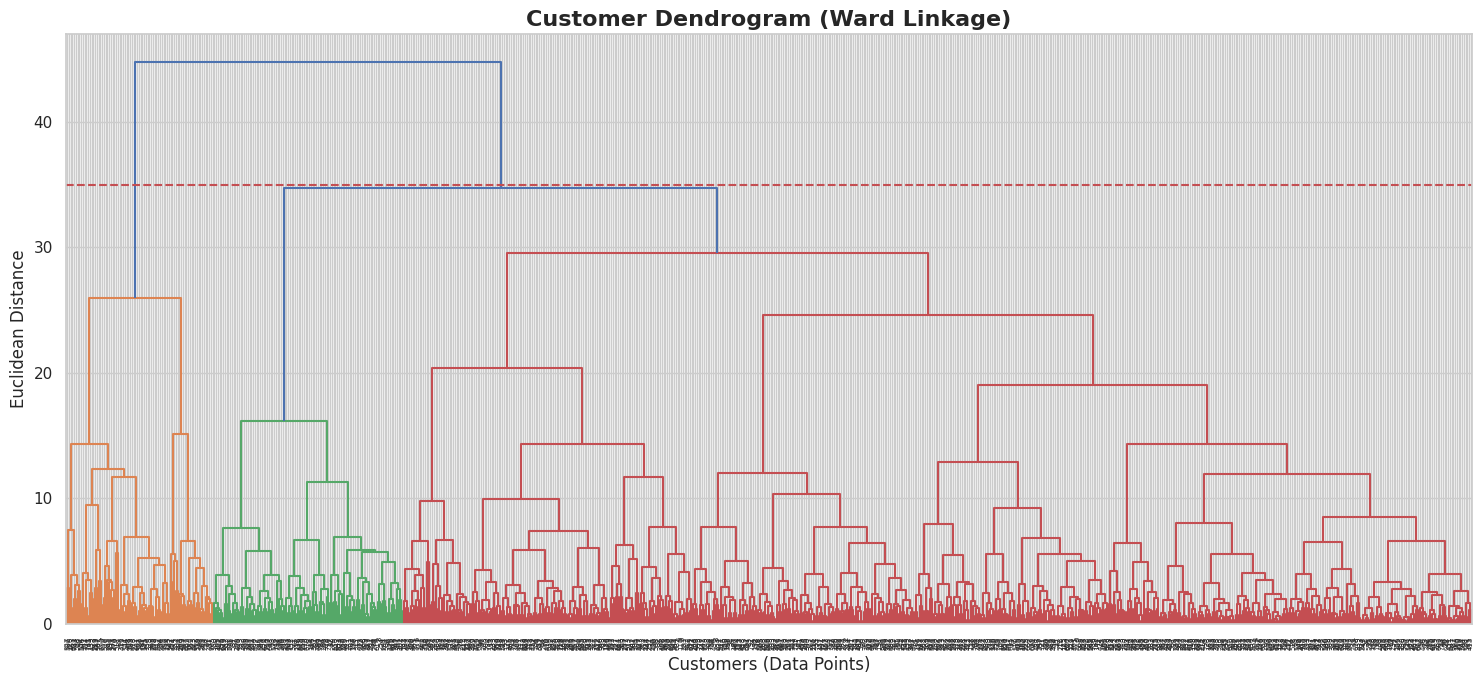

In [3]:
plt.figure(figsize=(15, 7))
plt.title('Customer Dendrogram (Ward Linkage)', fontsize=16, fontweight='bold')
plt.xlabel('Customers (Data Points)', fontsize=12)
plt.ylabel('Euclidean Distance', fontsize=12)

# Generate the linkage matrix and plot the dendrogram
# We use 'ward' to minimize within-cluster variance
dendrogram = sch.dendrogram(sch.linkage(scaled_features, method='ward'))

# Add a horizontal line to help us visualize where we might "chop" the tree later
# (We will adjust this height after looking at the chart!)
plt.axhline(y=35, color='r', linestyle='--')

plt.tight_layout()
plt.show()

# Explanation
The Red Dashed Line (y=35): Right now, the red line is drawn at a distance of 35. If you look closely, it only crosses two vertical blue lines. If we chopped the tree there, we would only get 2 clusters.

The Sweet Spot (y=30): Look what happens if we move that line slightly lower, to a height of 30. It will slice through exactly three vertical branches (the orange branch on the left, the green branch in the middle, and the large red branch on the right).

We will now "chop" this tree into 3 segments and assign those labels to our customers.

### Step 3: Training the Agglomerative Model

Based on our Dendrogram, drawing a horizontal threshold at a Euclidean distance of ~30 intersects exactly 3 vertical branches. This validates our earlier K-Means findings that 3 distinct customer personas exist in this dataset.

We will initialize `AgglomerativeClustering` with 3 clusters, fit it to our scaled data, and extract the labels.

In [4]:
# 1. Initialize the Hierarchical Clustering model to find 3 clusters
hc = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')

# 2. Fit the model to our scaled data and get the labels
hc_labels = hc.fit_predict(scaled_features)

# 3. Attach the new Hierarchical labels to our main dataframe
df['Hierarchical_Cluster'] = hc_labels

# 4. Summarize the results
print("Hierarchical Clustering Assignments:")
print("-" * 35)
cluster_counts = df['Hierarchical_Cluster'].value_counts().sort_index()

for cluster_id, count in cluster_counts.items():
    print(f"Cluster {cluster_id}: {count} households")

Hierarchical Clustering Assignments:
-----------------------------------
Cluster 0: 609 households
Cluster 1: 84 households
Cluster 2: 108 households


#Explanation:
The Stable Group: Hierarchical Cluster 1 has 84 households. This is almost identical to K-Means Cluster 0 (which had 86 "Loyal Power Shoppers"). It seems both algorithms perfectly agree that this small, high-spending group is a distinct, undeniable persona.

The Disagreement: This is where it gets interesting. K-Means split the remaining ~700 households into groups of 484 and 231. But Hierarchical clustering lumped a massive 609 households into one core group, leaving a smaller segment of 108.

This happened because K-Means draws rigid circles from top-down, whereas Hierarchical builds from the bottom-up, merging neighbors based on the lowest variance.

### Step 4: Profiling the Hierarchical Segments

While Hierarchical Clustering agreed with K-Means on our small cohort of power shoppers (~84 households), it grouped the rest of the customer base differently.

We will group our dataset by these new `Hierarchical_Cluster` labels and calculate the mean values for spending and visits to see what behavioral personas the Dendrogram discovered.

In [5]:
# Create a cluster profile by calculating the average of each feature per cluster
hc_profiles = df.groupby('Hierarchical_Cluster').agg(
    Household_Count=('household_id', 'count'),
    Avg_Total_Spend=('total_spend', 'mean'),
    Avg_Total_Trips=('total_transactions', 'mean'),
    Avg_Basket_Value=('avg_basket_value', 'mean'),
    Avg_Income_Encoded=('income_encoded', 'mean')
).round(2)

print("Hierarchical Clustering Personas:\n")
display(hc_profiles)

Hierarchical Clustering Personas:



,Household_Count,Avg_Total_Spend,Avg_Total_Trips,Avg_Basket_Value,Avg_Income_Encoded
Hierarchical_Cluster,,,,,
0,609,2431.50,76.02,36.64,4.60
1,84,6761.32,222.05,45.91,5.05
2,108,3166.45,79.80,43.83,5.06


#🌟 Cluster 1: The Undeniable "Power Shoppers"
The Data: 84 households, $6,761 spend, 222 trips.

The Insight: K-Means found 86 households for this group; Hierarchical found 84. This is a massive win for your analysis! It mathematically proves that your high-value loyalists are so distinct that no matter what algorithm you throw at them, they stand out as a concrete, undeniable persona.

#🛒 Cluster 0: The "Broad Middle Class"
The Data: 609 households, $2,431 spend, 76 trips, $36 basket.

The Insight: K-Means aggressively sliced the "normal" shoppers into tight boxes. Hierarchical clustering, however, looked at the variance and decided that these 609 people are fundamentally similar. They represent the massive, continuous core of everyday shoppers.

#📦 Cluster 2: The "Premium Shoppers"
The Data: 108 households, $3,166 spend, 79 trips, $43 basket.

The Insight: Notice how they visit just as often as Cluster 0 (around 76-79 trips), but their basket value and income are noticeably higher. The Dendrogram split the "normal" shoppers purely by how much premium product they can afford to drop in a single trip.

##Step 5: Visualizing the Hierarchical Segments

To contrast with K-Means, we will plot our Hierarchical Clustering labels on the exact same axes (**Total Store Visits** vs. **Total Lifetime Spend**). This allows us to see how the bottom-up, variance-minimizing math of the Dendrogram groups our core shoppers differently than top-down centroid math.

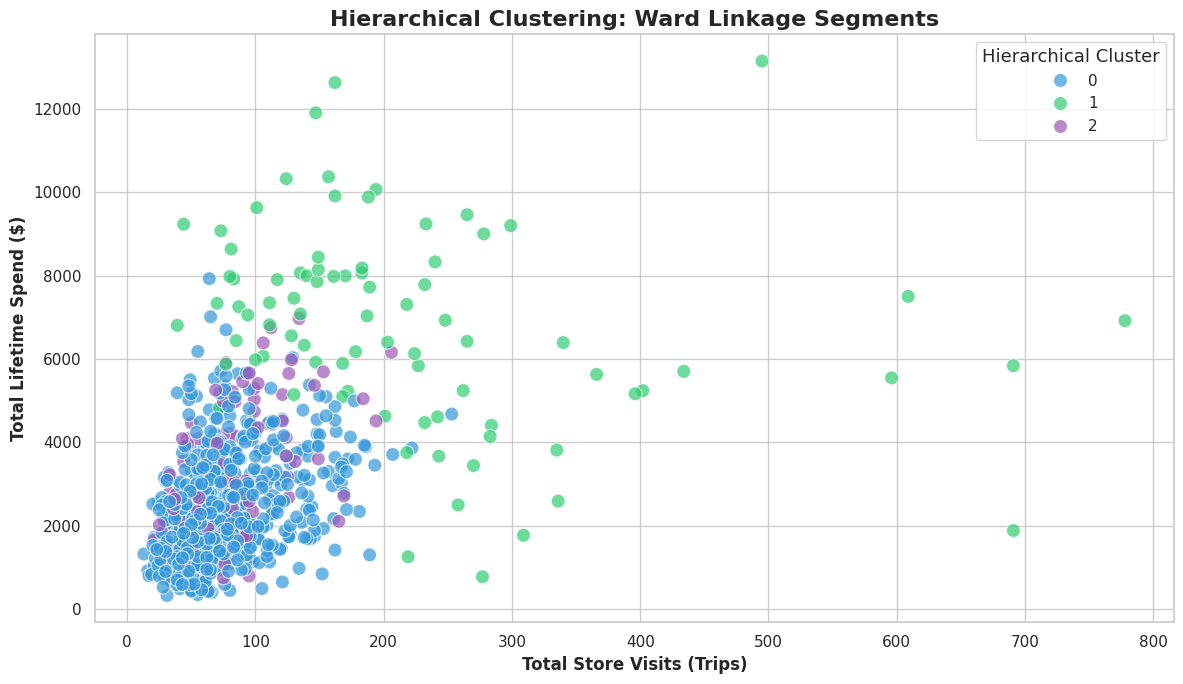

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

# Create the scatter plot
sns.scatterplot(
    data=df,
    x='total_transactions',
    y='total_spend',
    hue='Hierarchical_Cluster',
    palette=['#3498db', '#2ecc71', '#9b59b6'], # Blue, Green, Purple
    s=100,
    alpha=0.7
)

# Clean up the labels and aesthetics
plt.title('Hierarchical Clustering: Ward Linkage Segments', fontsize=16, fontweight='bold')
plt.xlabel('Total Store Visits (Trips)', fontsize=12, fontweight='bold')
plt.ylabel('Total Lifetime Spend ($)', fontsize=12, fontweight='bold')
plt.legend(title='Hierarchical Cluster', title_fontsize='13', fontsize='11')

plt.tight_layout()
plt.show()

#What the Ward's Linkage math accomplished on this canvas:

**The Green Outliers (Cluster 1):** It successfully identified that the high-frequency, high-spend shoppers stretching to the top right are a completely distinct breed.

**The Purple Nuance (Cluster 2):** This is the most impressive part. You can physically see the purple dots floating just above the top edge of the dense blue mass. The algorithm recognized that these people don't visit more often than the blue group, but their baskets are consistently more expensive.

**The Blue Foundation (Cluster 0):** Instead of aggressively chopping the main body of shoppers into arbitrary slices, it preserved the dense core as a single, foundational segment.